In [1]:
using ImageFiltering

function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end


gaussian_smooth (generic function with 1 method)

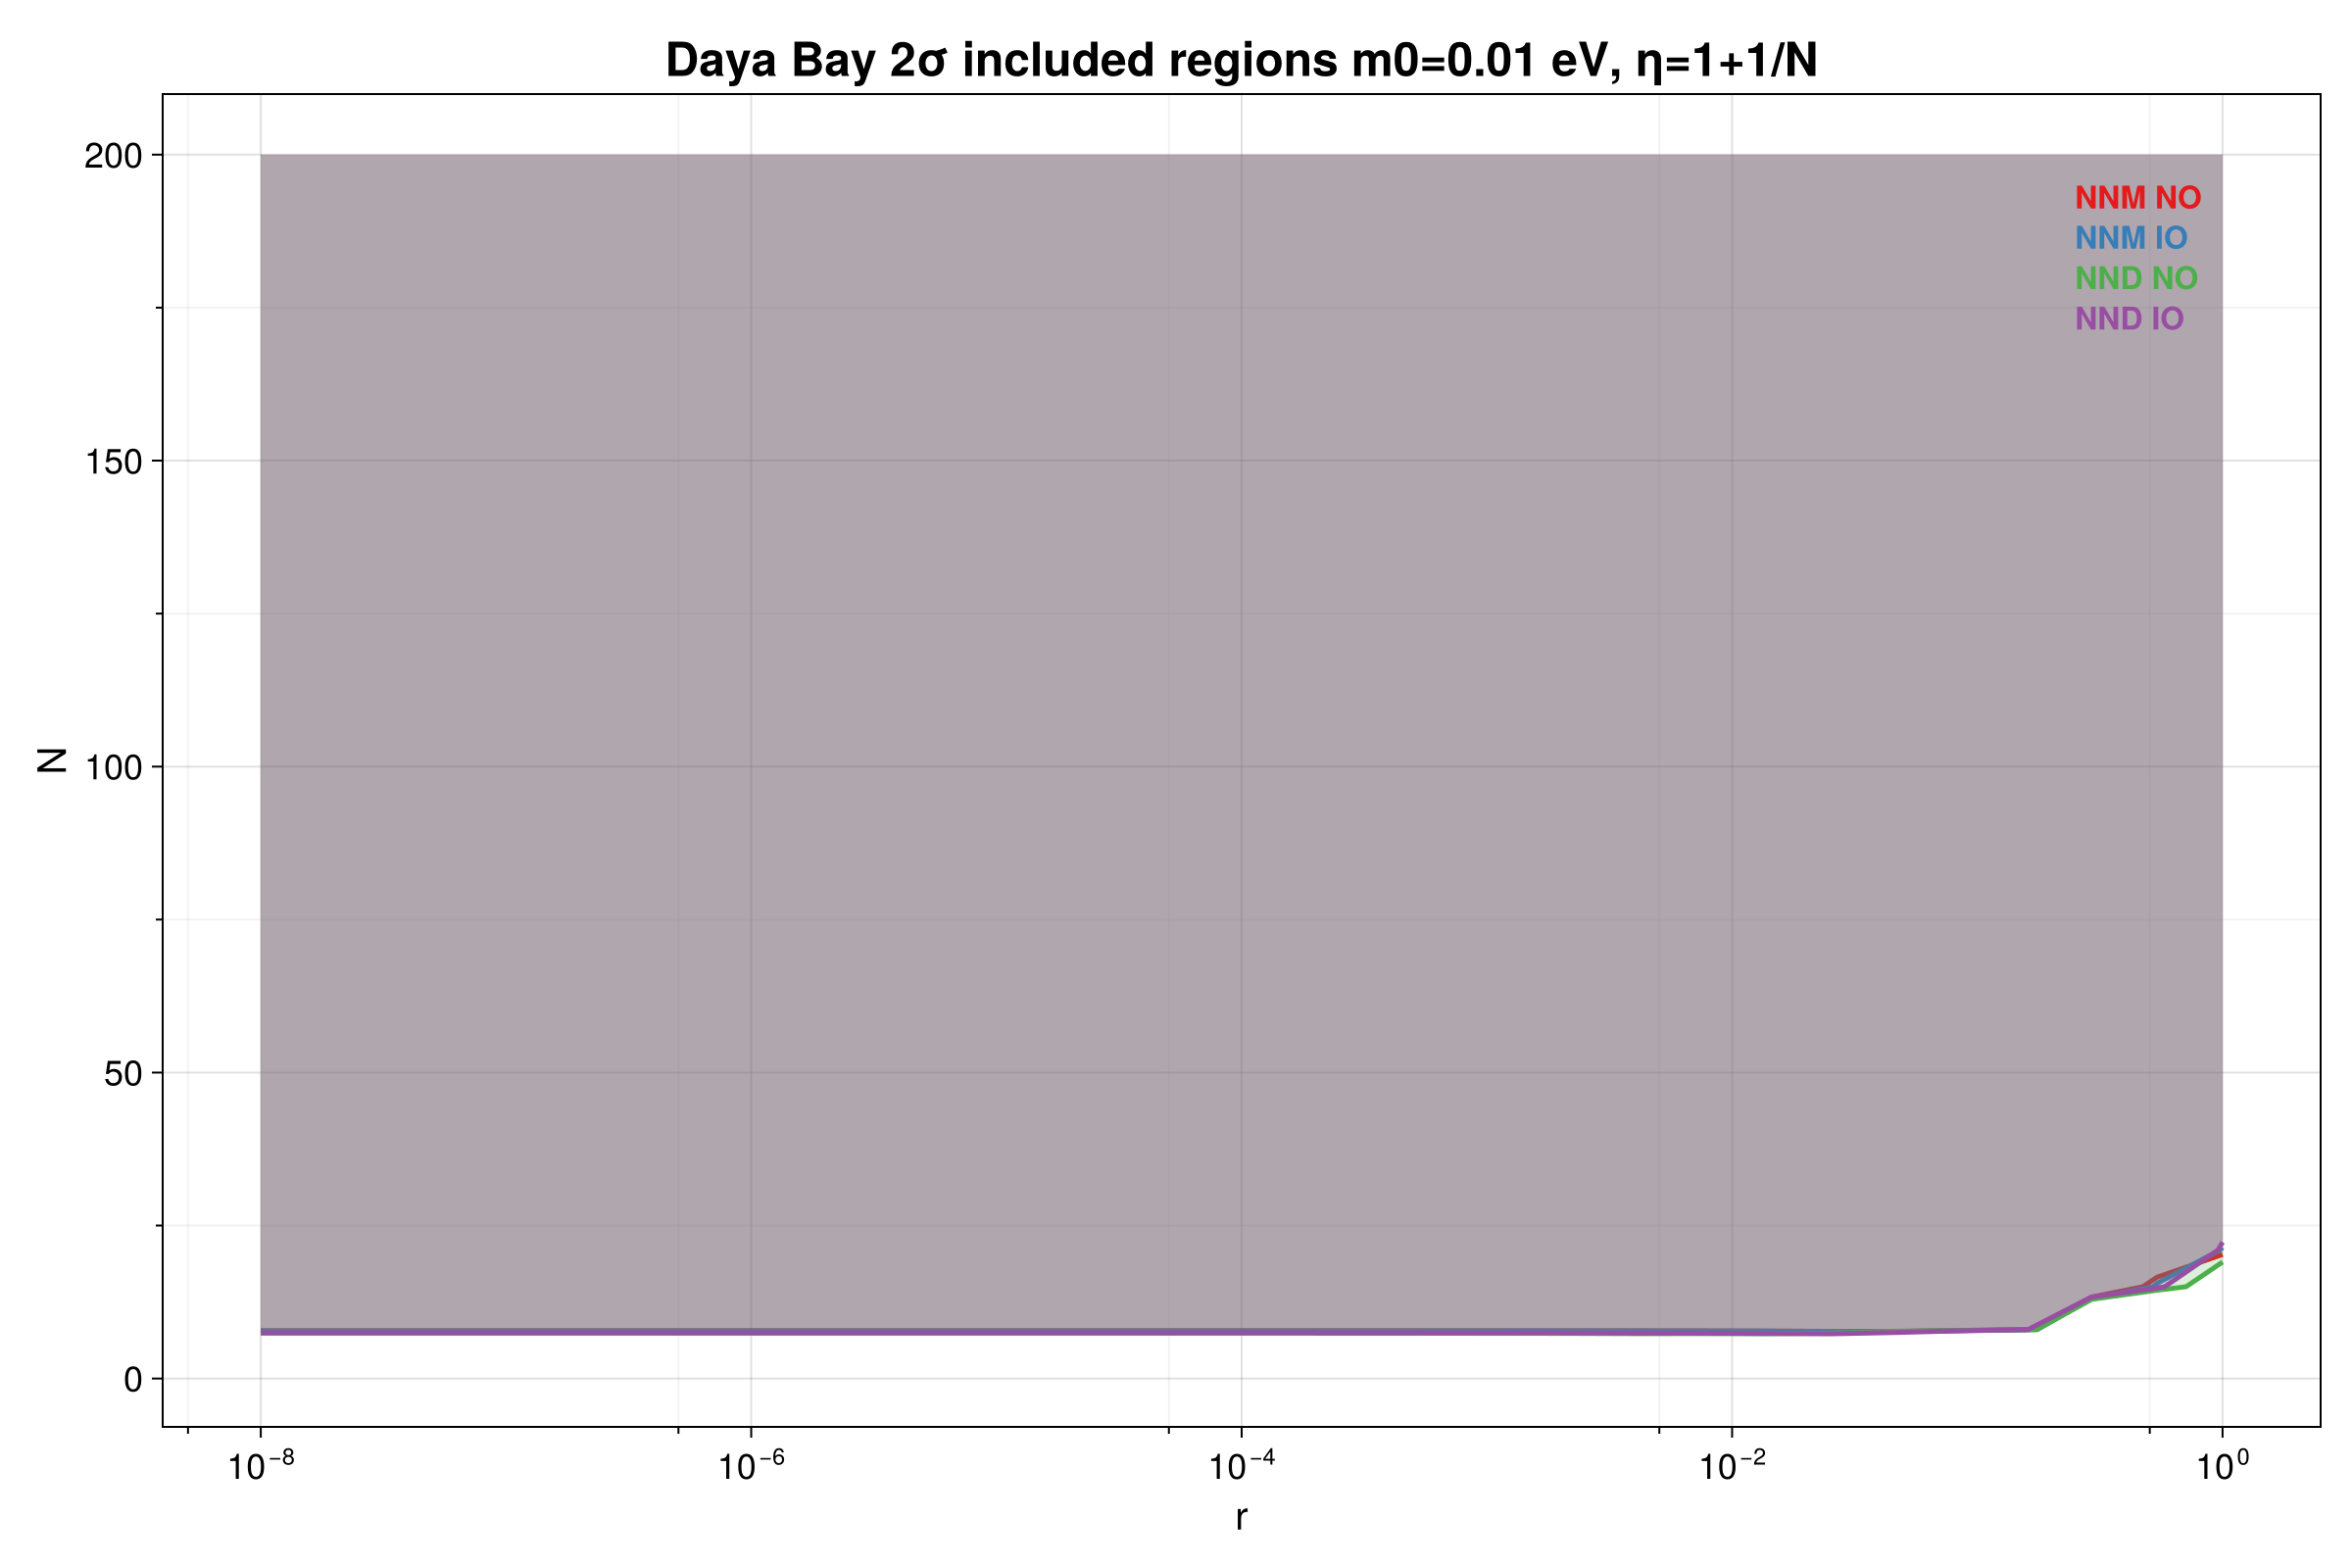

CairoMakie.Screen{IMAGE}


In [2]:
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos

function superpose_contours(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    
    # Calculate 2σ level
    sigma_2_level = quantile(Chisq(2), 1 - 2*ccdf(Normal(), 2))
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*"(eV)"
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 24,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18,
        xscale = xscale,
        yscale = yscale
    )
    
    # Plot contours
    for (idx, result) in enumerate(results)
        dLLH = 2 * (maximum(result.values.log_posterior) .- result.values.log_posterior)
        
        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]
        
        # Create transparent version of the color
        color_transparent = RGBA(color, 1)
        color_transparent_full = RGBA(color, 0.2)
        
        contourf!(ax, result.axes[1], result.axes[2], dLLH,
            levels = [0, sigma_2_level],
            colormap = cgrad([color_transparent_full, color_transparent])) 
        
        # Overlay the contour line on top
        contour!(ax, result.axes[1], result.axes[2], dLLH,
            levels = [sigma_2_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle)
    end
    
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.25)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end

file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NNM_log.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NNM_IO_log.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NND_NO_log.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NND_IO_log.jld2"]
                
fig = superpose_contours(file_paths;  
    title="Daya Bay 2σ included regions m0=0.01 eV, η=1+1/N",
    experiments = ["NNM NO", "NNM IO", "NND NO", "NND IO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10
    )

display(fig)
#save("/home/sofialon/Newtrinos.jl/plots_fix/plots_new/superposed_contours_dayabaylog_rN.png", fig)

[ Info: Precompiling Newtrinos [5b289081-bab5-45e8-97fc-86872f1653a0] (cache misses: include_dependency fsize change (2), wrong dep version loaded (2))
[ Info: Setting new default BAT context BATContext{Float64}(Random123.Philox4x{UInt64, 10}(0xa10da46825f77a24, 0xa95ee5f74f95663d, 0xa66d2c51400164a9, 0x44547b91aa73d3e0, 0x35f87bfae80c7c91, 0x4c9ed975b613eb82, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0x0000000000000000, 0), HeterogeneousComputing.CPUnit(), BAT._NoADSelected())


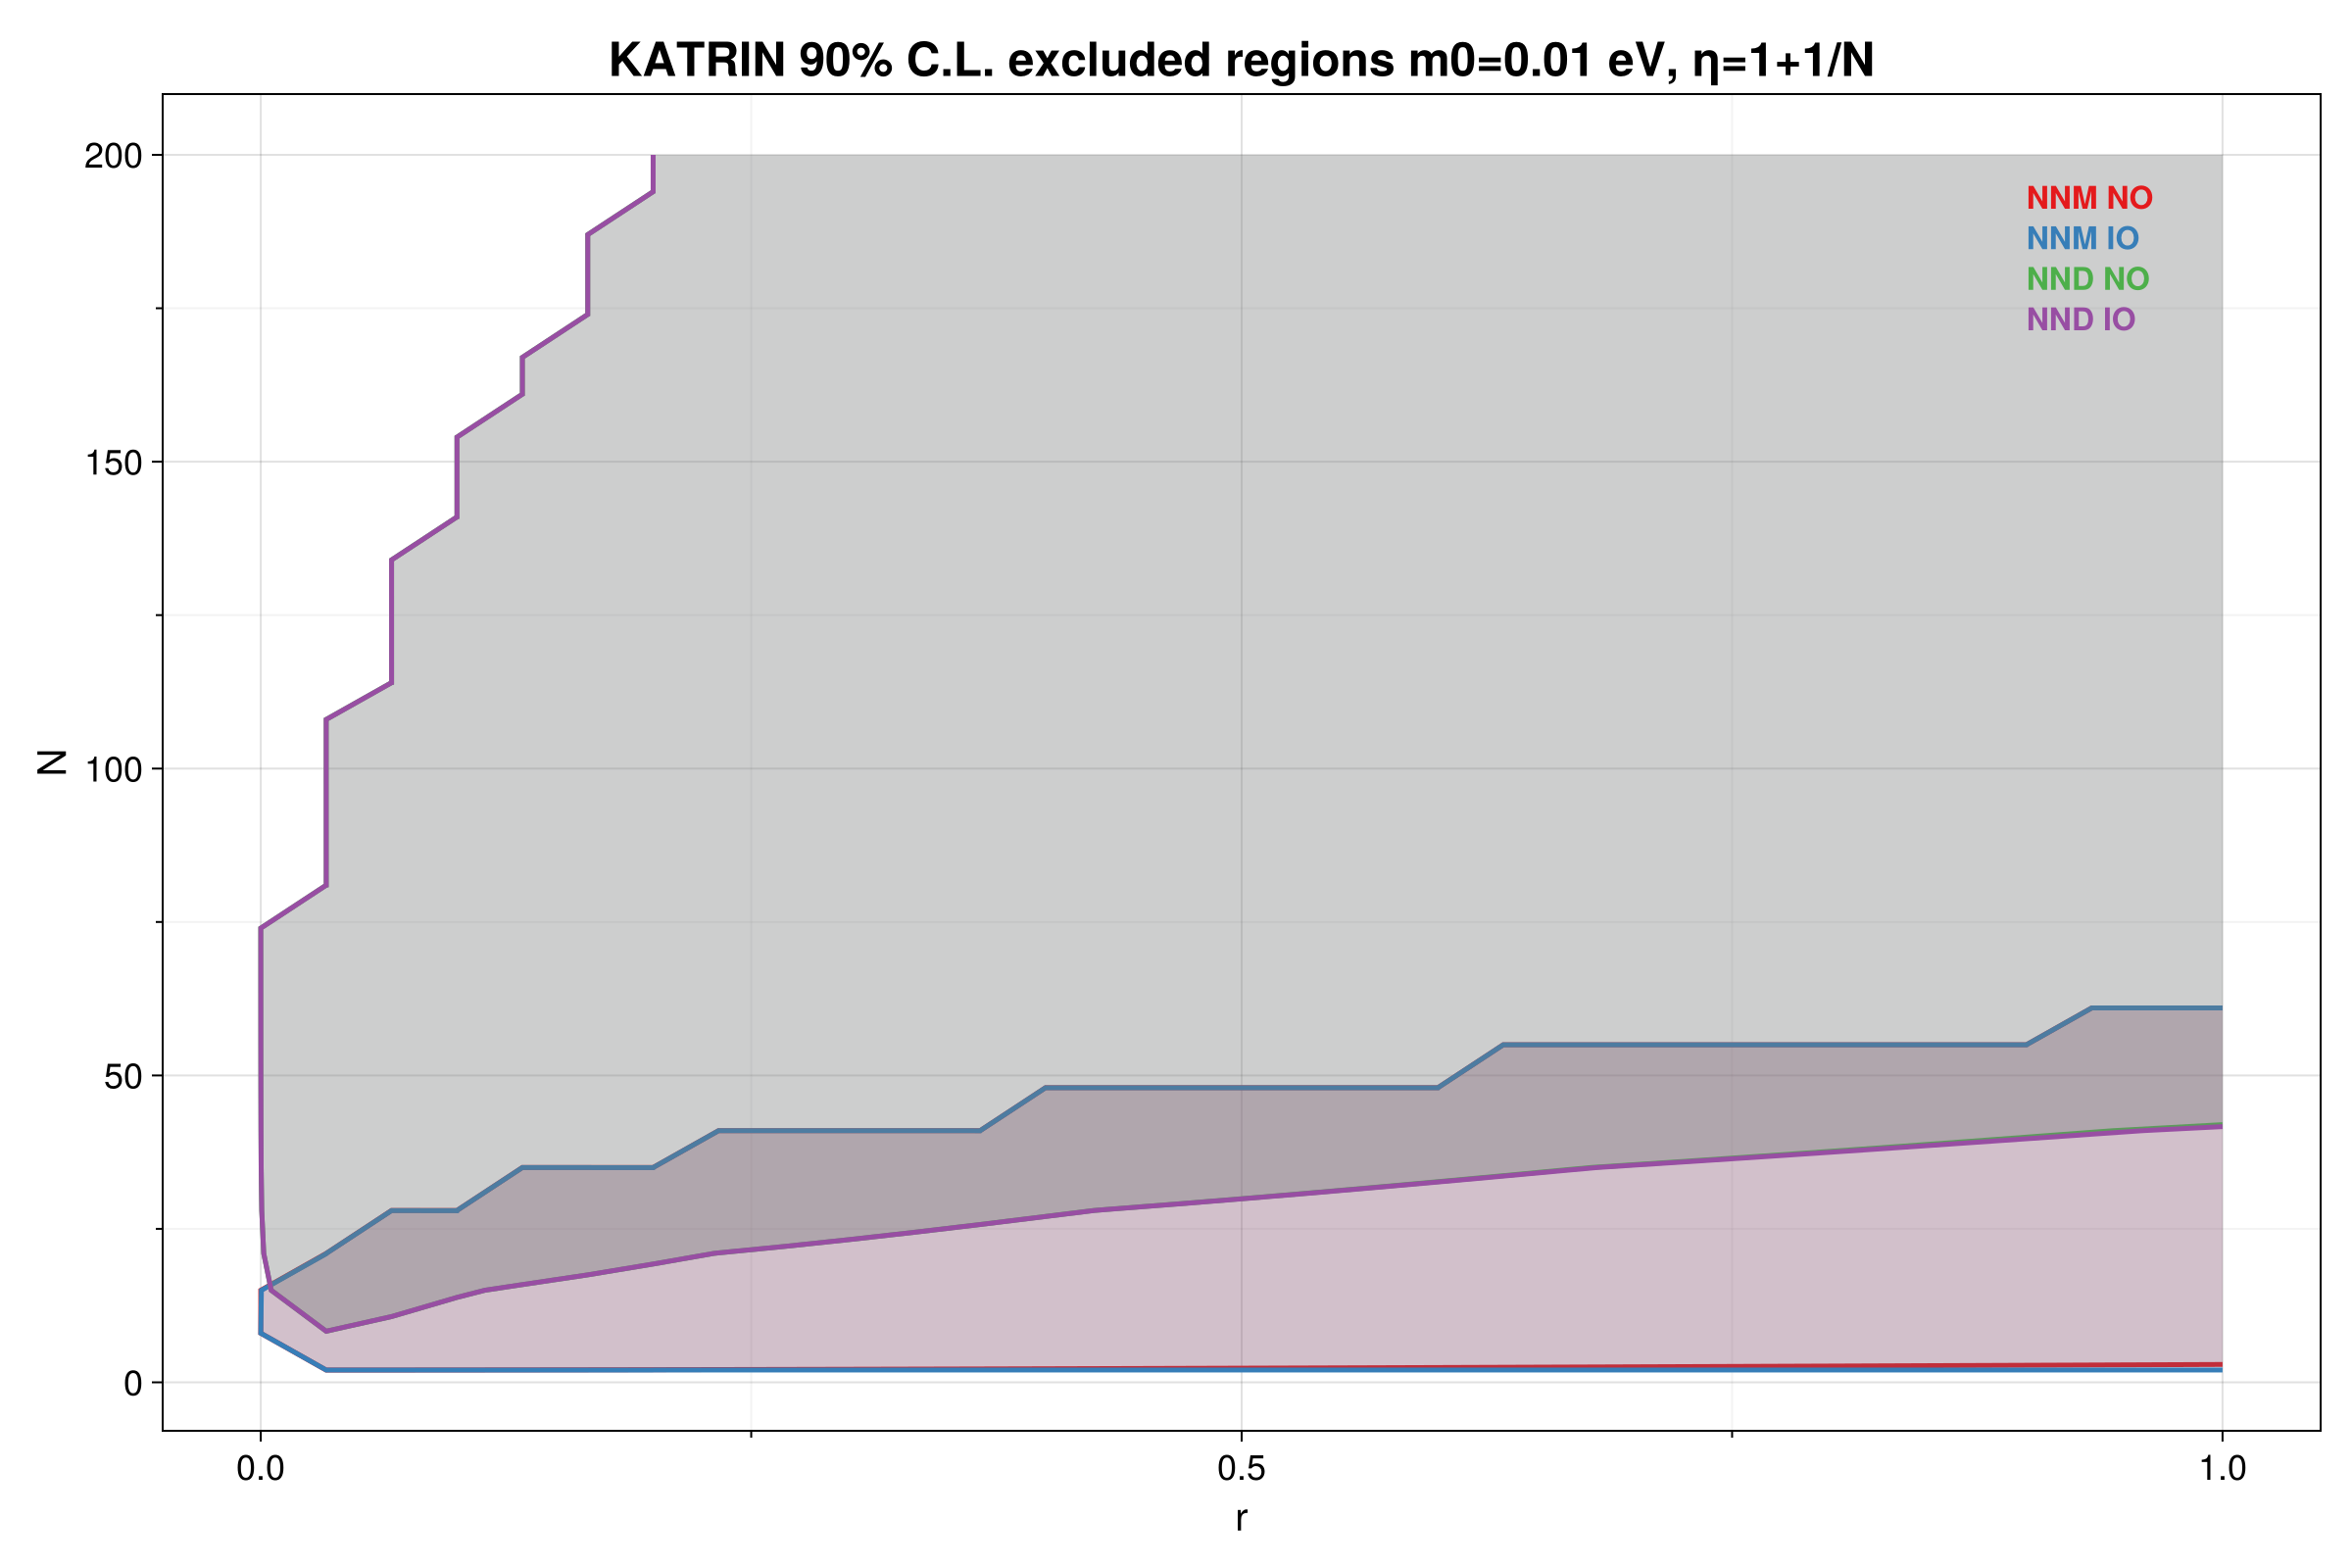

In [2]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos


function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end



function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*"(eV)"
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 24,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)

        dLLH_raw = 2 .* (maximum(result.values.log_posterior) .- result.values.log_posterior)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        # --- CLEAN FIELD (critical) ---
        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.9)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_Nr_m0=0.01_η=1+1N_NNM_IO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_Nr_m0=0.01_η=1+1N_NND_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_Nr_m0=0.01_η=1+1N_NND_IO.jld2"]
                
fig = superpose_contours_outside(file_paths;  
    title="KATRIN 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["NNM NO", "NNM IO", "NND NO", "NND IO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    #xscale=log10,
    #yscale=log10
    smooth_sigma=nothing)

display(fig)
save("/home/sofialon/Newtrinos.jl/plots_fix/plots_newex/superposed_contours_katrin_rN.png", fig)



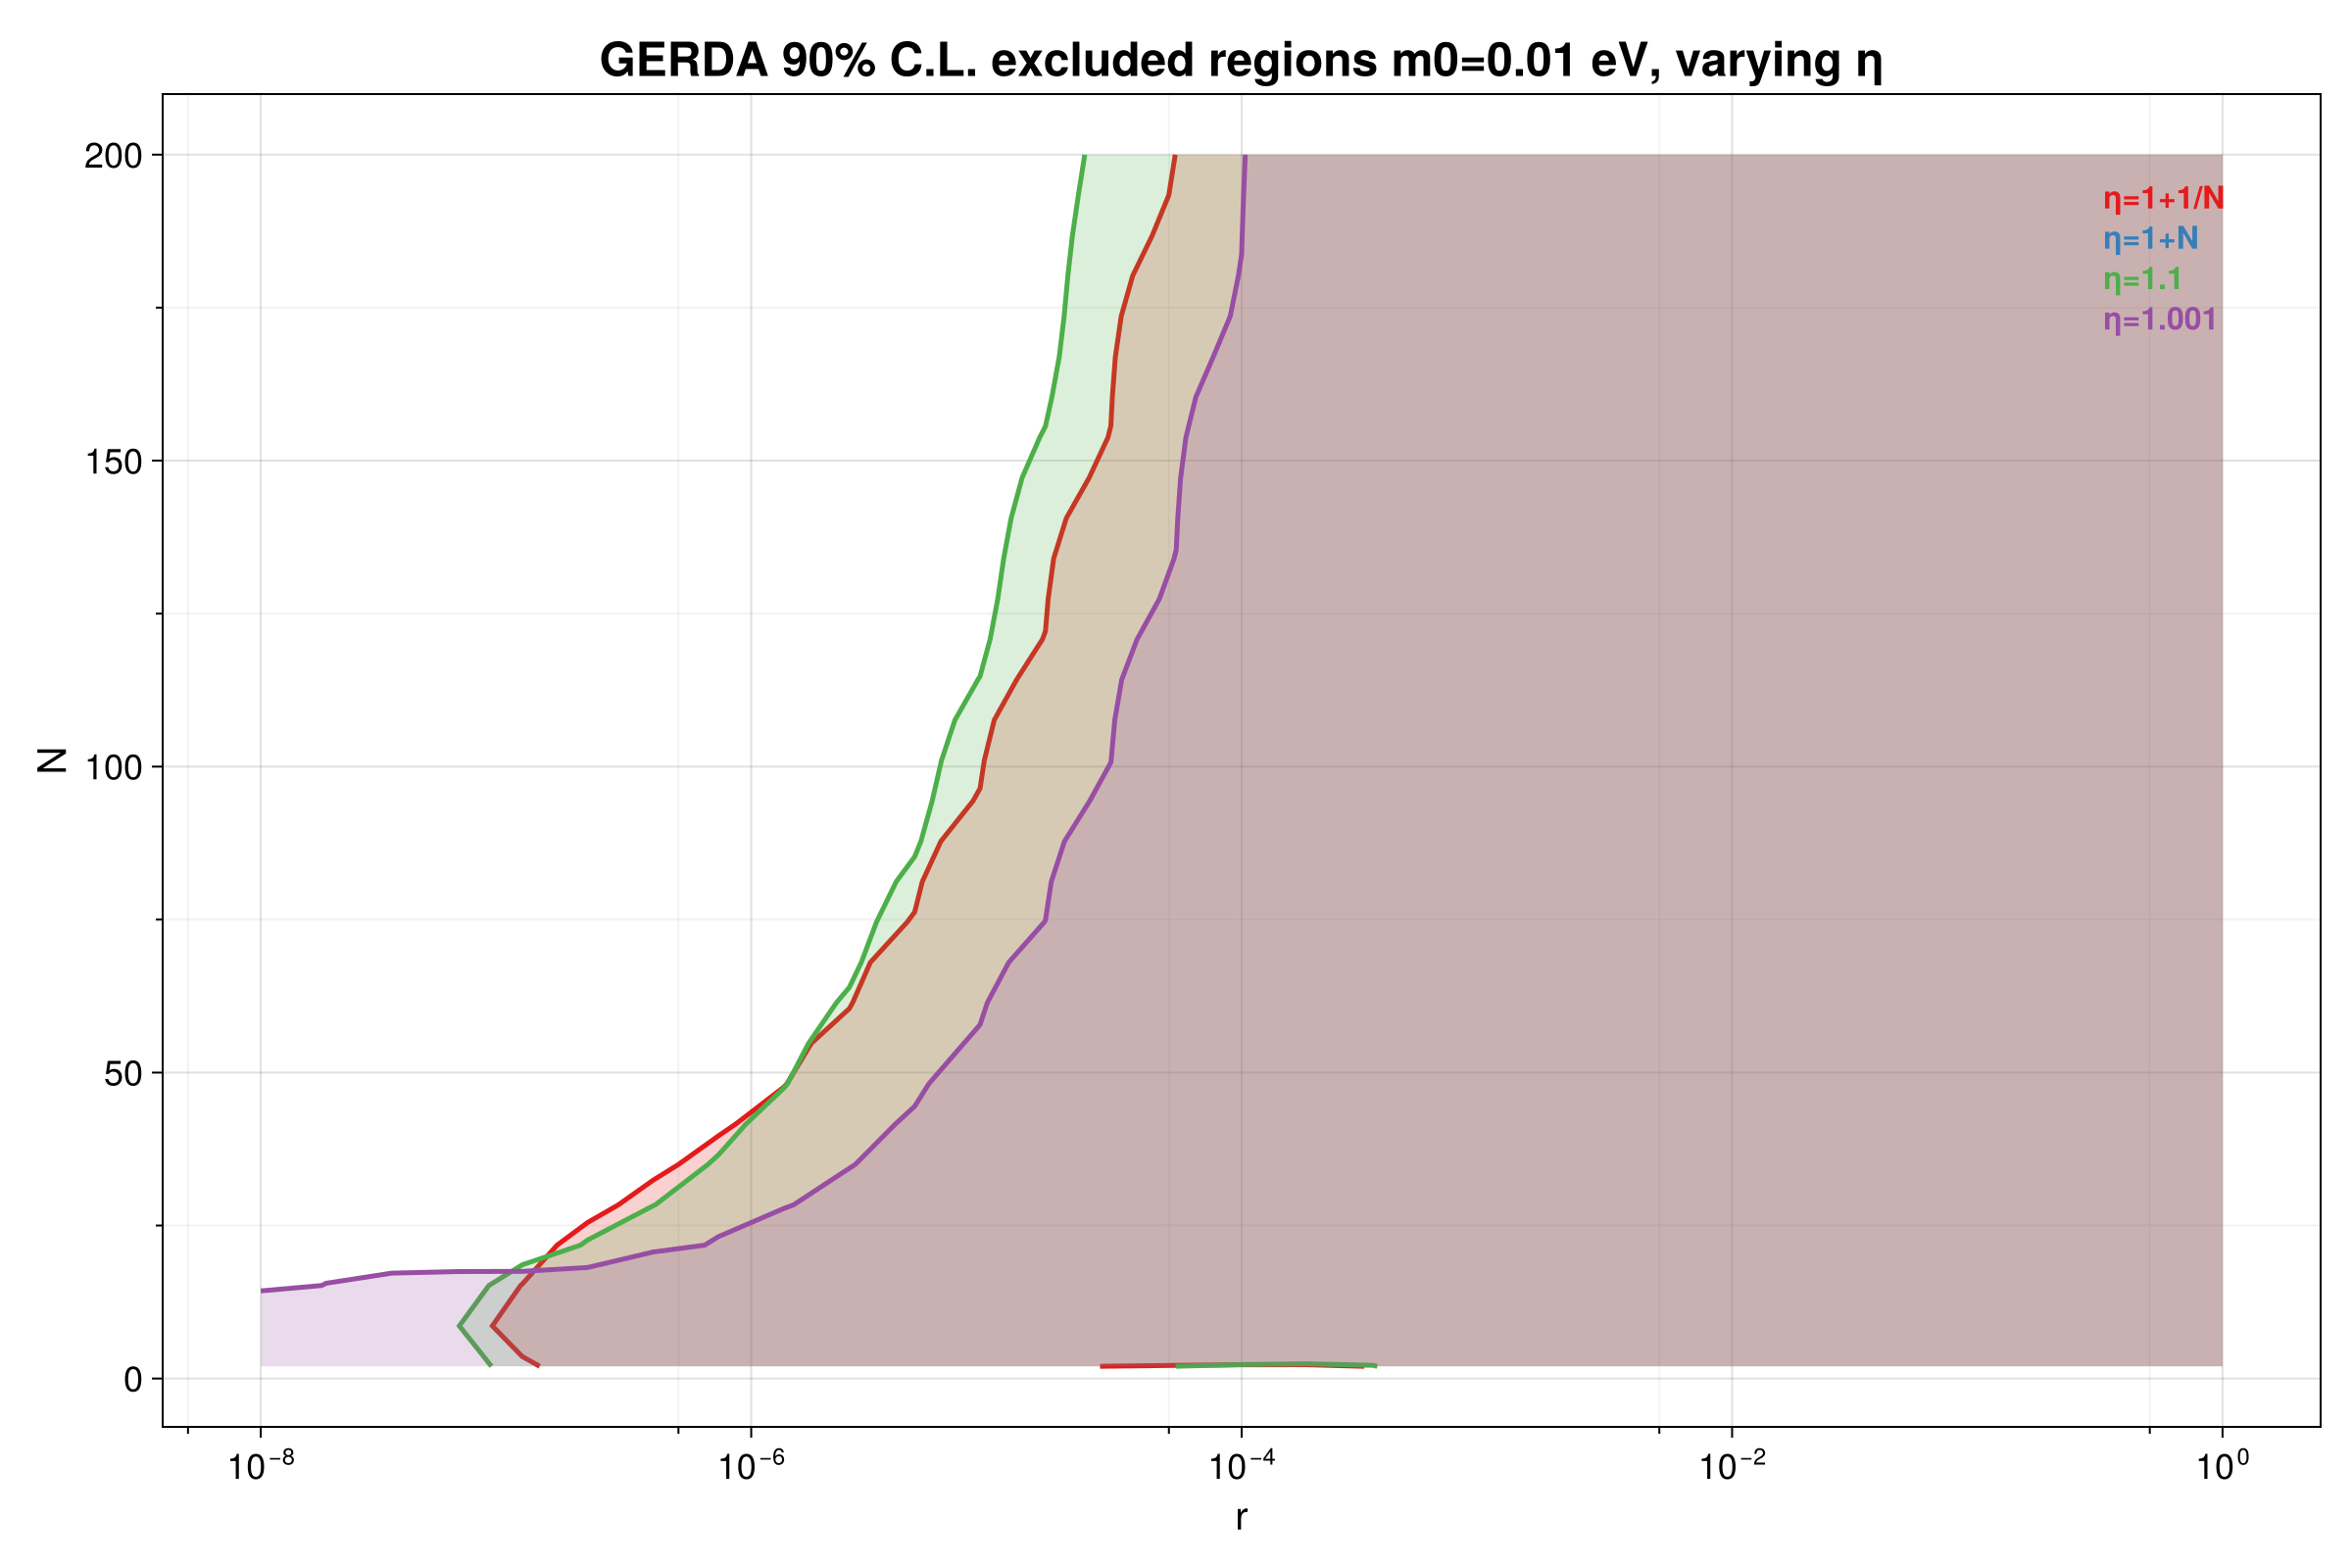

In [7]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos


function gaussian_smooth(Z; σ=1.0)
    kernel = Kernel.gaussian((σ, σ))
    return imfilter(Z, kernel, Pad(:replicate))
end



function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*"(eV)"
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 24,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)

        dLLH_raw = 2 .* (maximum(result.values.log_posterior) .- result.values.log_posterior)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)

        # --- CLEAN FIELD (critical) ---
        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.3)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1+1N_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1+N_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1.1_NNM_NO.jld2",
                "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1.001_NNM_NO.jld2"]
                
fig = superpose_contours_outside(file_paths;  
    title="GERDA 90% C.L. excluded regions m0=0.01 eV, varying η",
    experiments = [" η=1+1/N", " η=1+N", " η=1.1", " η=1.001"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10
    smooth_sigma=0.8)

display("image/png", fig)
save("/home/sofialon/Newtrinos.jl/plots_fix/plots_newex/superposed_contours_gerda_rN_eta.png", fig)



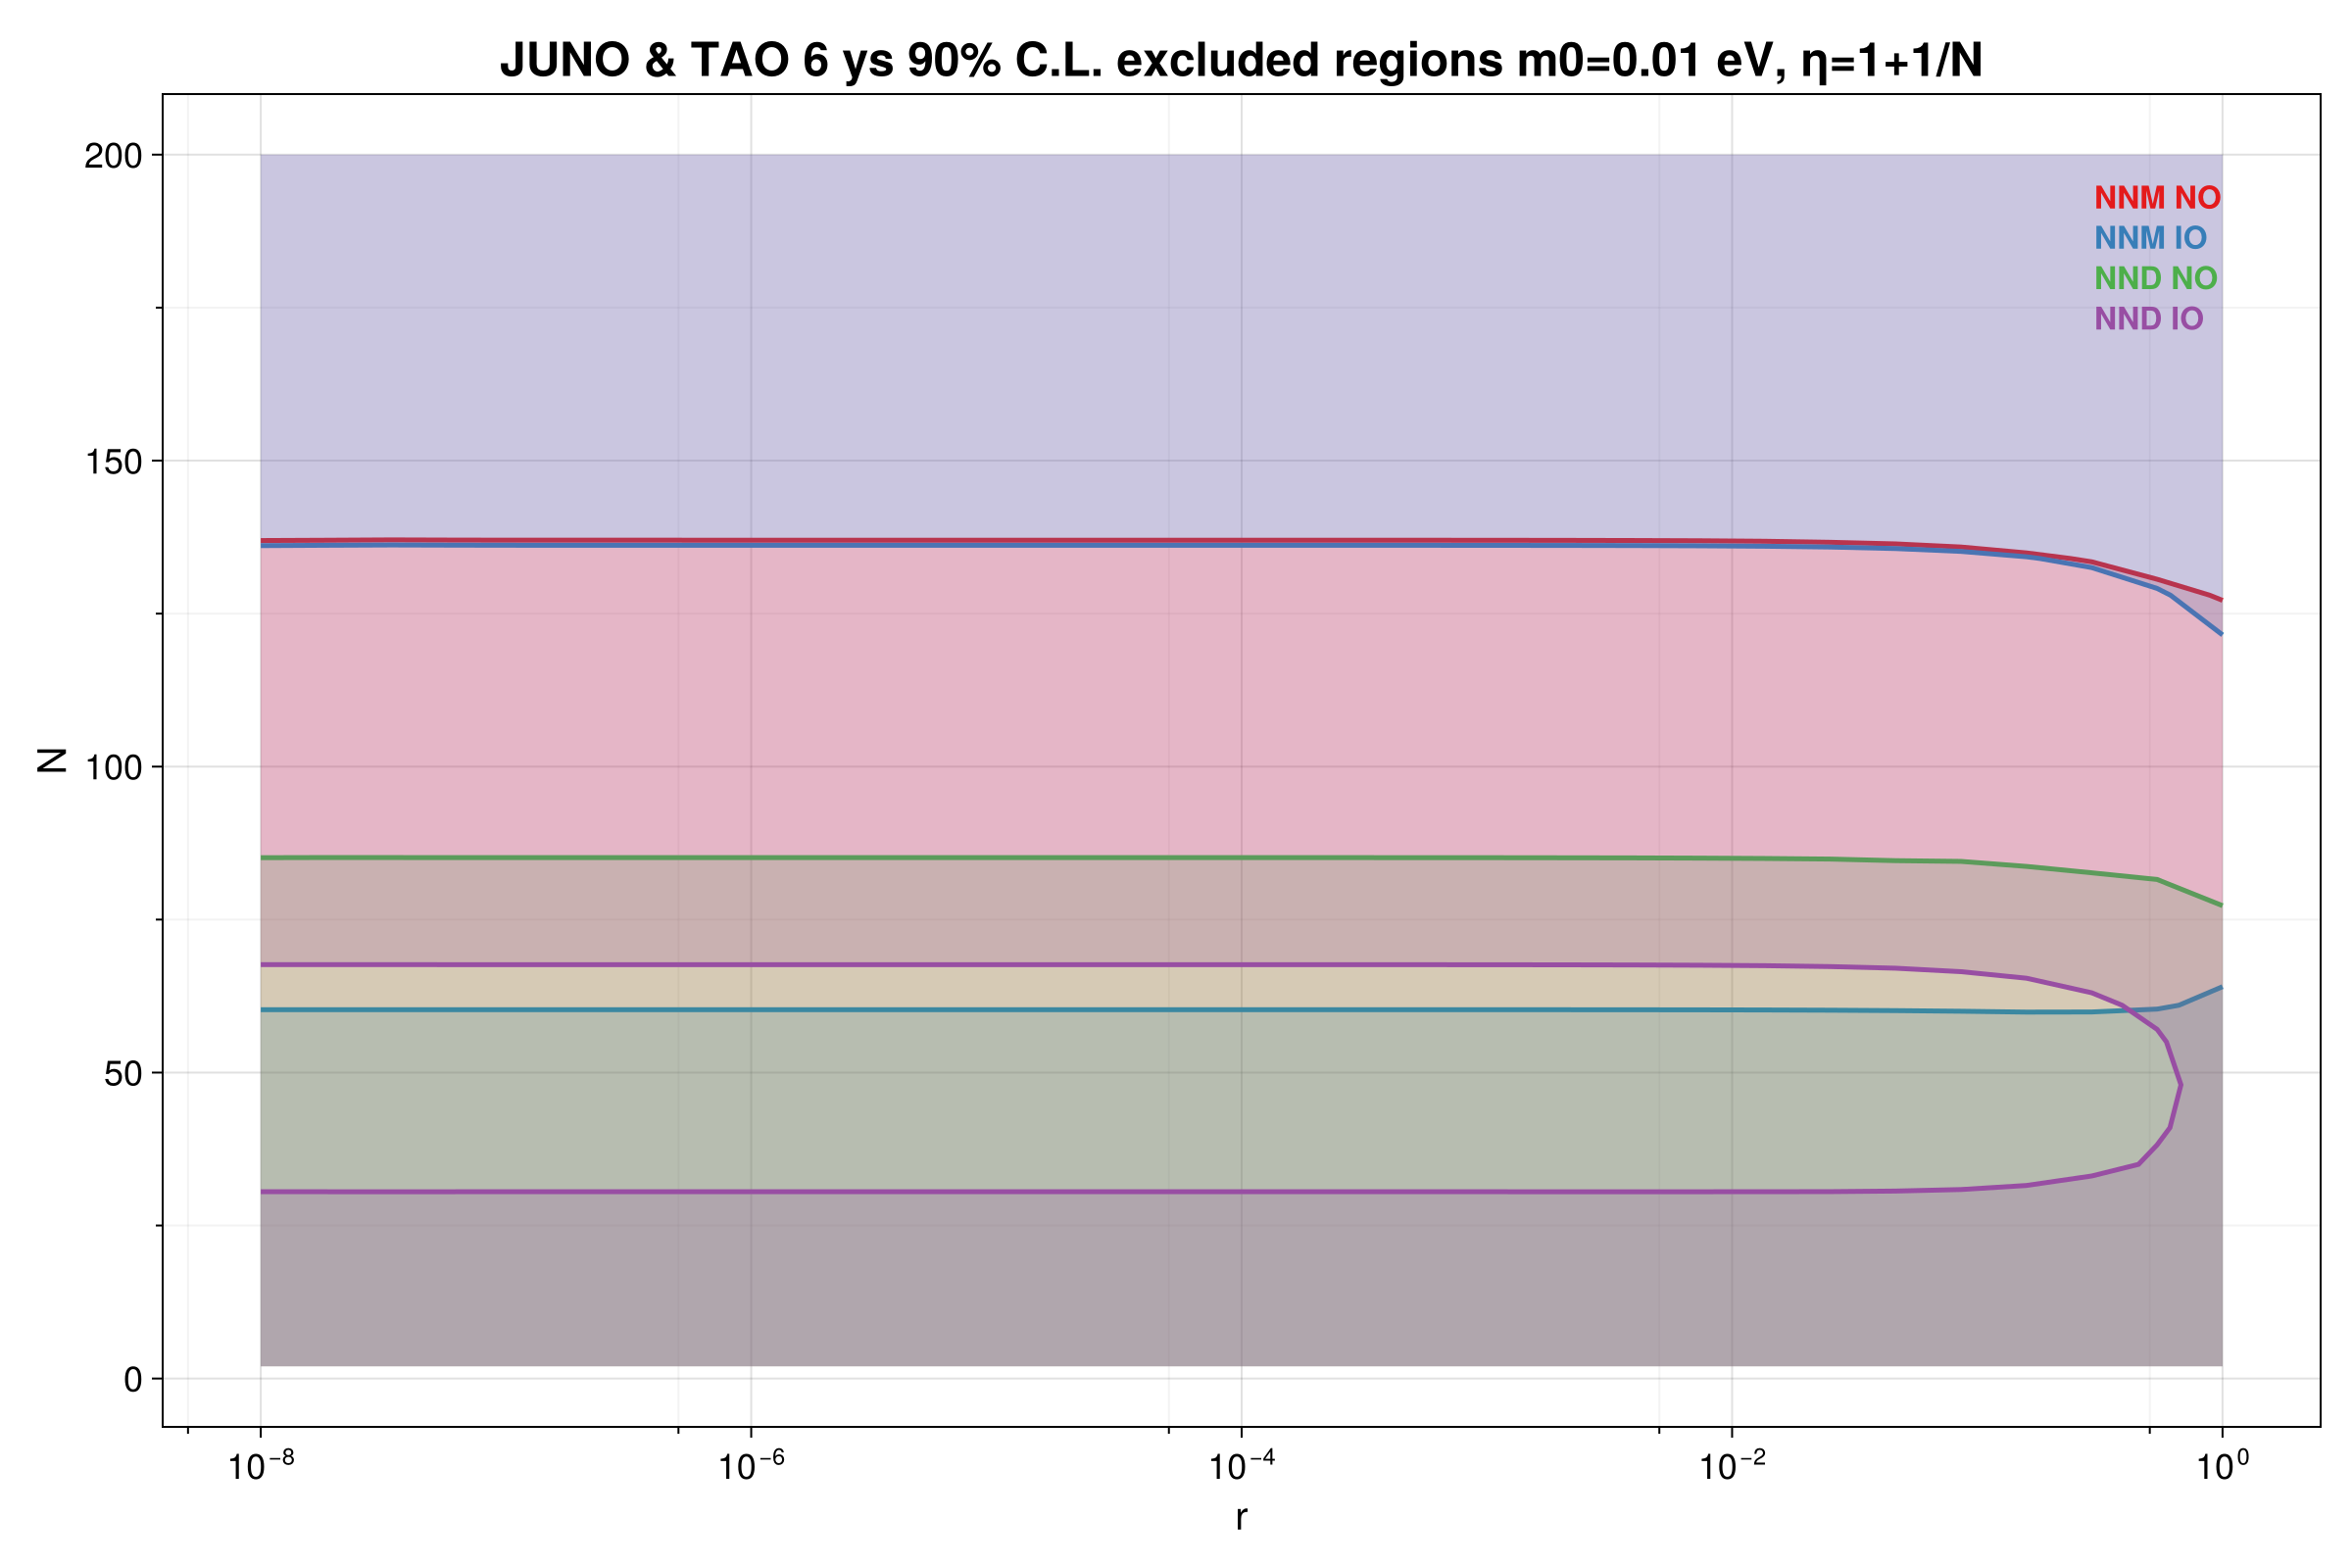

In [14]:



function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*" (eV)"
        ylabel = String(axis_labels[2]) ,
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 24,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)
        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            @warn "Scan contains no finite likelihood values — skipping"
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)


        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
      
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.85, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.3)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_full6_rN_NNM_NO_η=1+1_N_m0=0.01_log.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_full6_rN_NNM_IO_η=1+1_N_m0=0.01_log.jld2",
                 "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_full6_rN_NND_NO_η=1+1_N_m0=0.01_log.jld2",
               "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_full6_rN_NND_IO_η=1+1_N_m0=0.01_log.jld2"]
    
                
fig = superpose_contours_outside(file_paths;  
    title="JUNO & TAO 6 ys 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["NNM NO", "NNM IO", "NND NO","NND IO"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10,
    smooth_sigma=nothing)

display("image/png",fig)
save("/home/sofialon/Newtrinos.jl/plots_fix/plots_newex/superposed_contours_juno6_rN_log.png", fig)


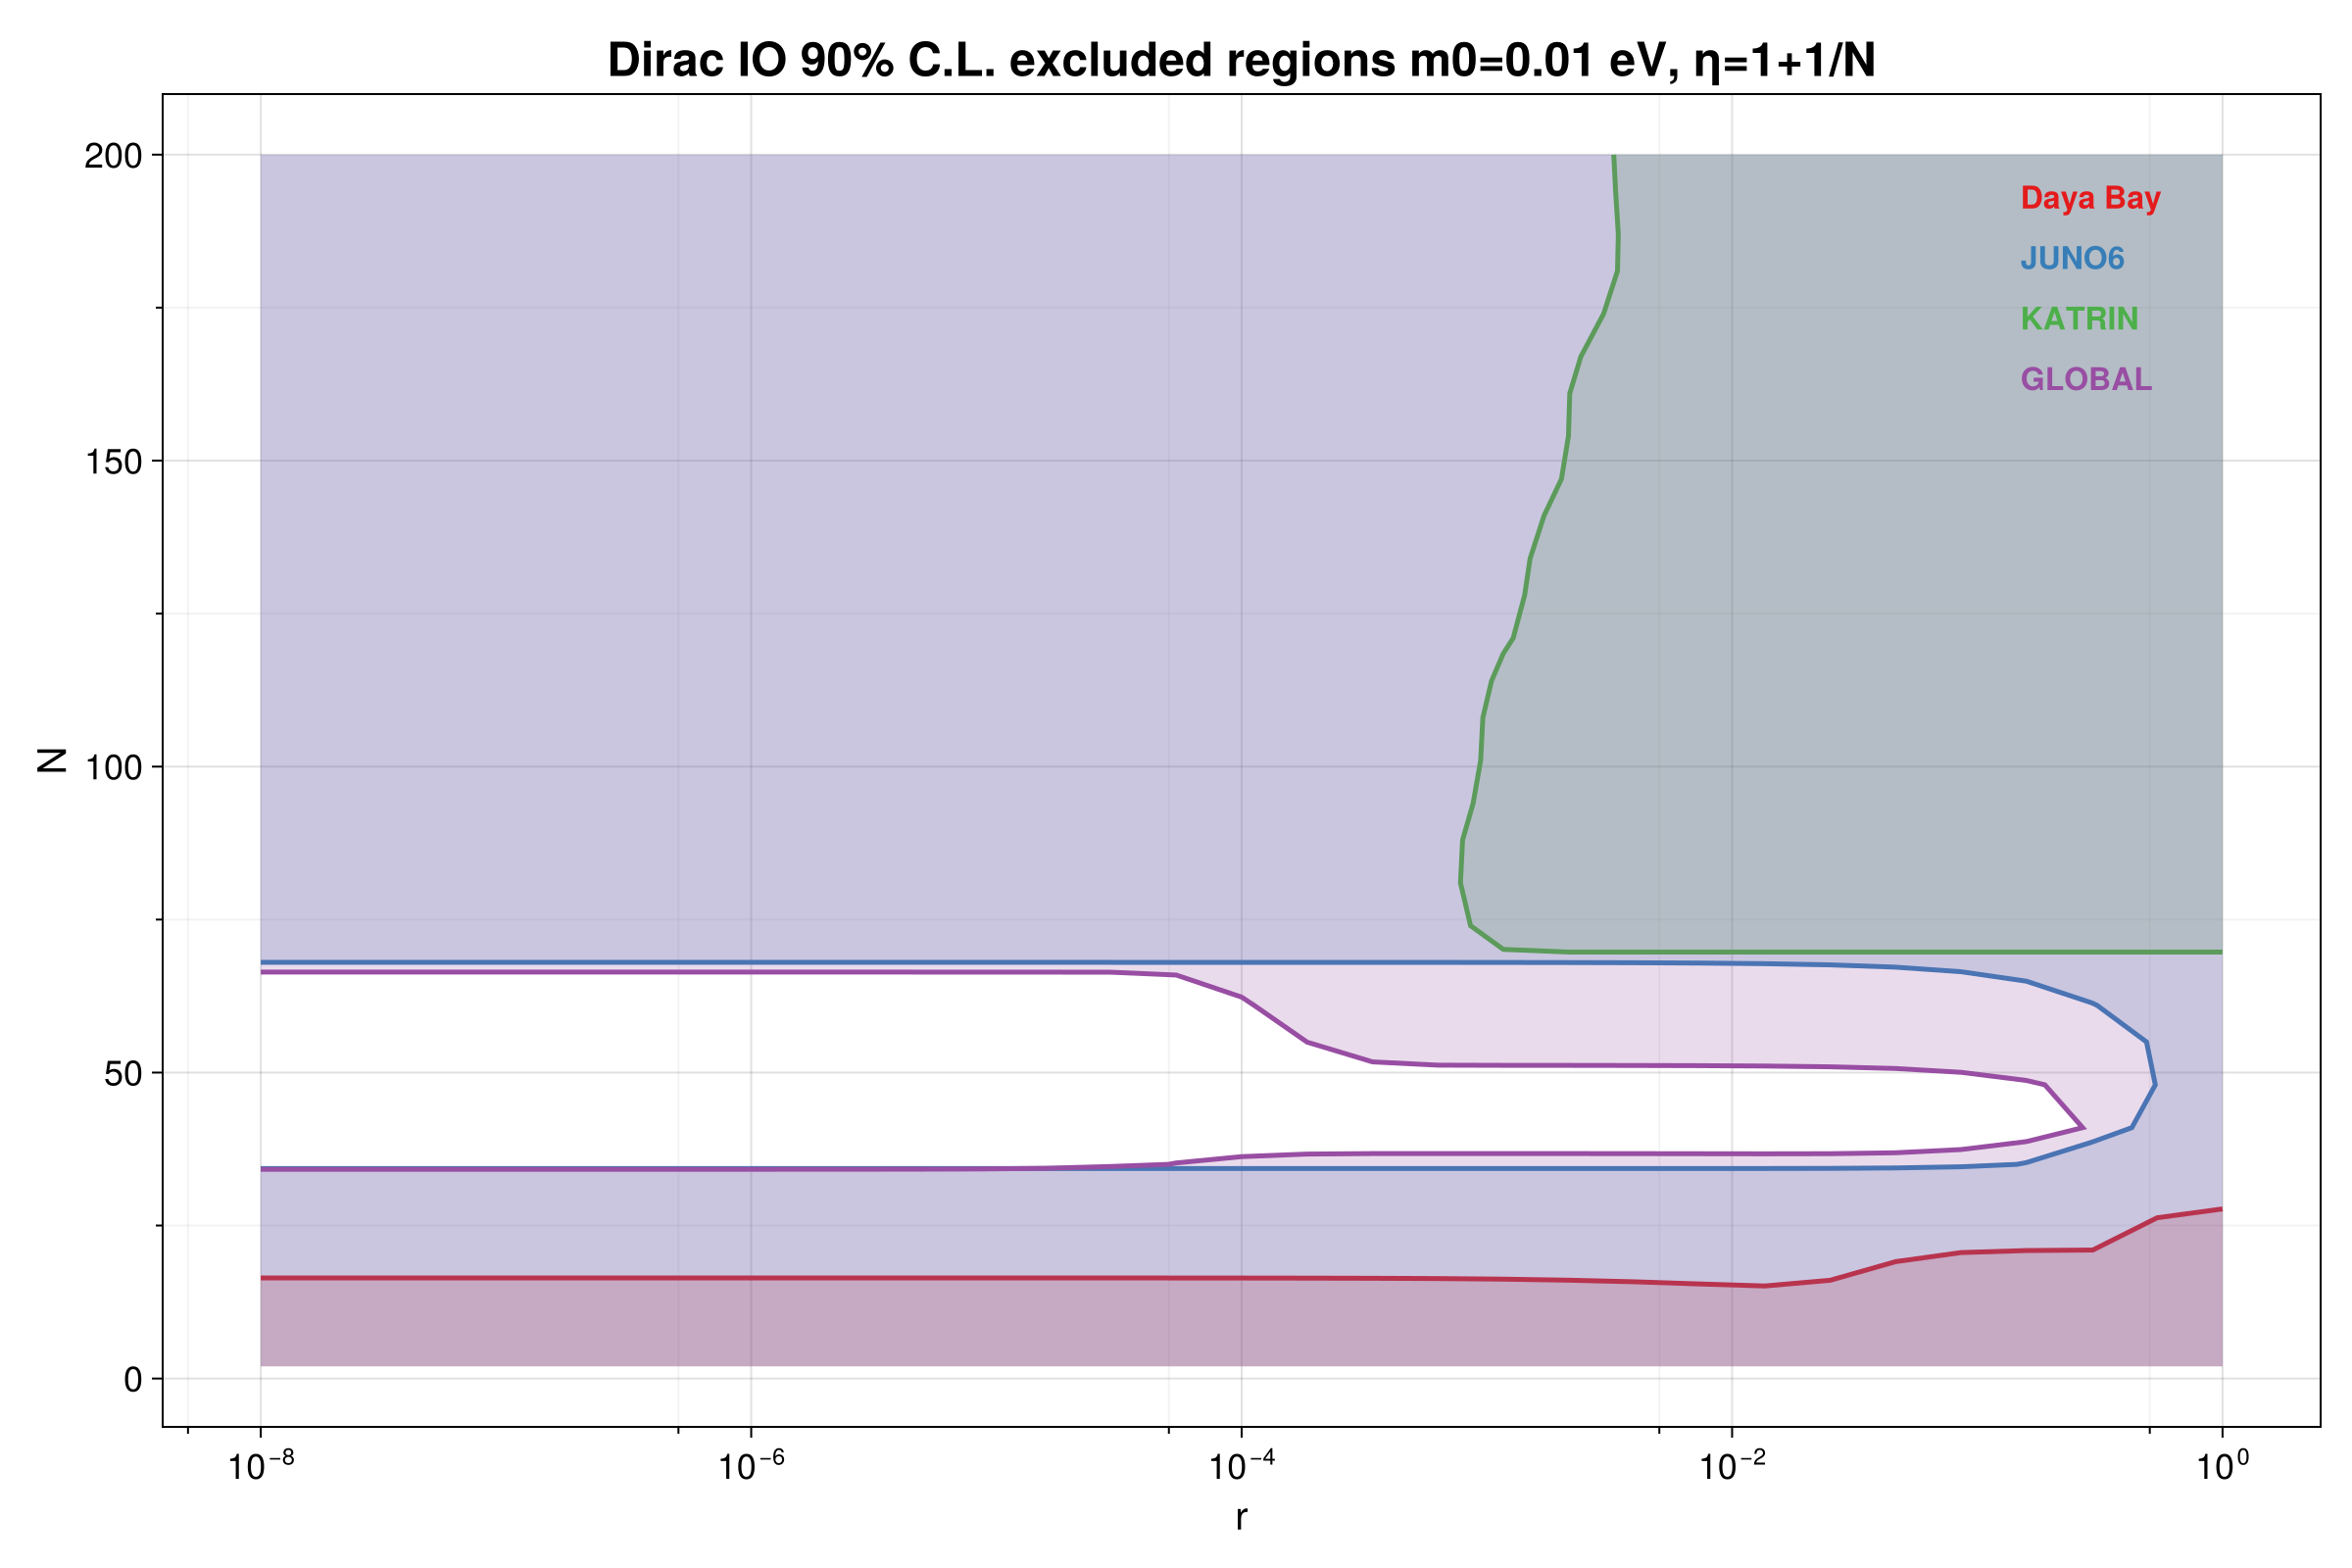

In [15]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos


function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*" (eV)"
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 24,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)
        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            @warn "Scan contains no finite likelihood values — skipping"
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)


        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
      
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.80, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.15)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NND_IO_log.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_full6_rN_NND_IO_η=1+1_N_m0=0.01_log.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_Nr_m0=0.01_η=1+1N_NND_IO.jld2",
              #"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1+1N_NND_IO.jld2",
              #"/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend200_Nr_m0=0.01_η=1+1N_NND_IO.jld2",
             # "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend1000_Nr_m0=0.01_η=1+1N_NND_IO.jld2",
             "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_global_rN_m0=0.01_NND_IO.jld2"
             ]
    
                
fig = superpose_contours_outside(file_paths;  
    title="Dirac IO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["Daya Bay","JUNO6", "KATRIN","GLOBAL"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10,
    smooth_sigma=1.0)

display("image/png",fig)
save("/home/sofialon/Newtrinos.jl/plots_fix/plots_newex/superposed_contours_allglobal_NND_IO_rn.png", fig)


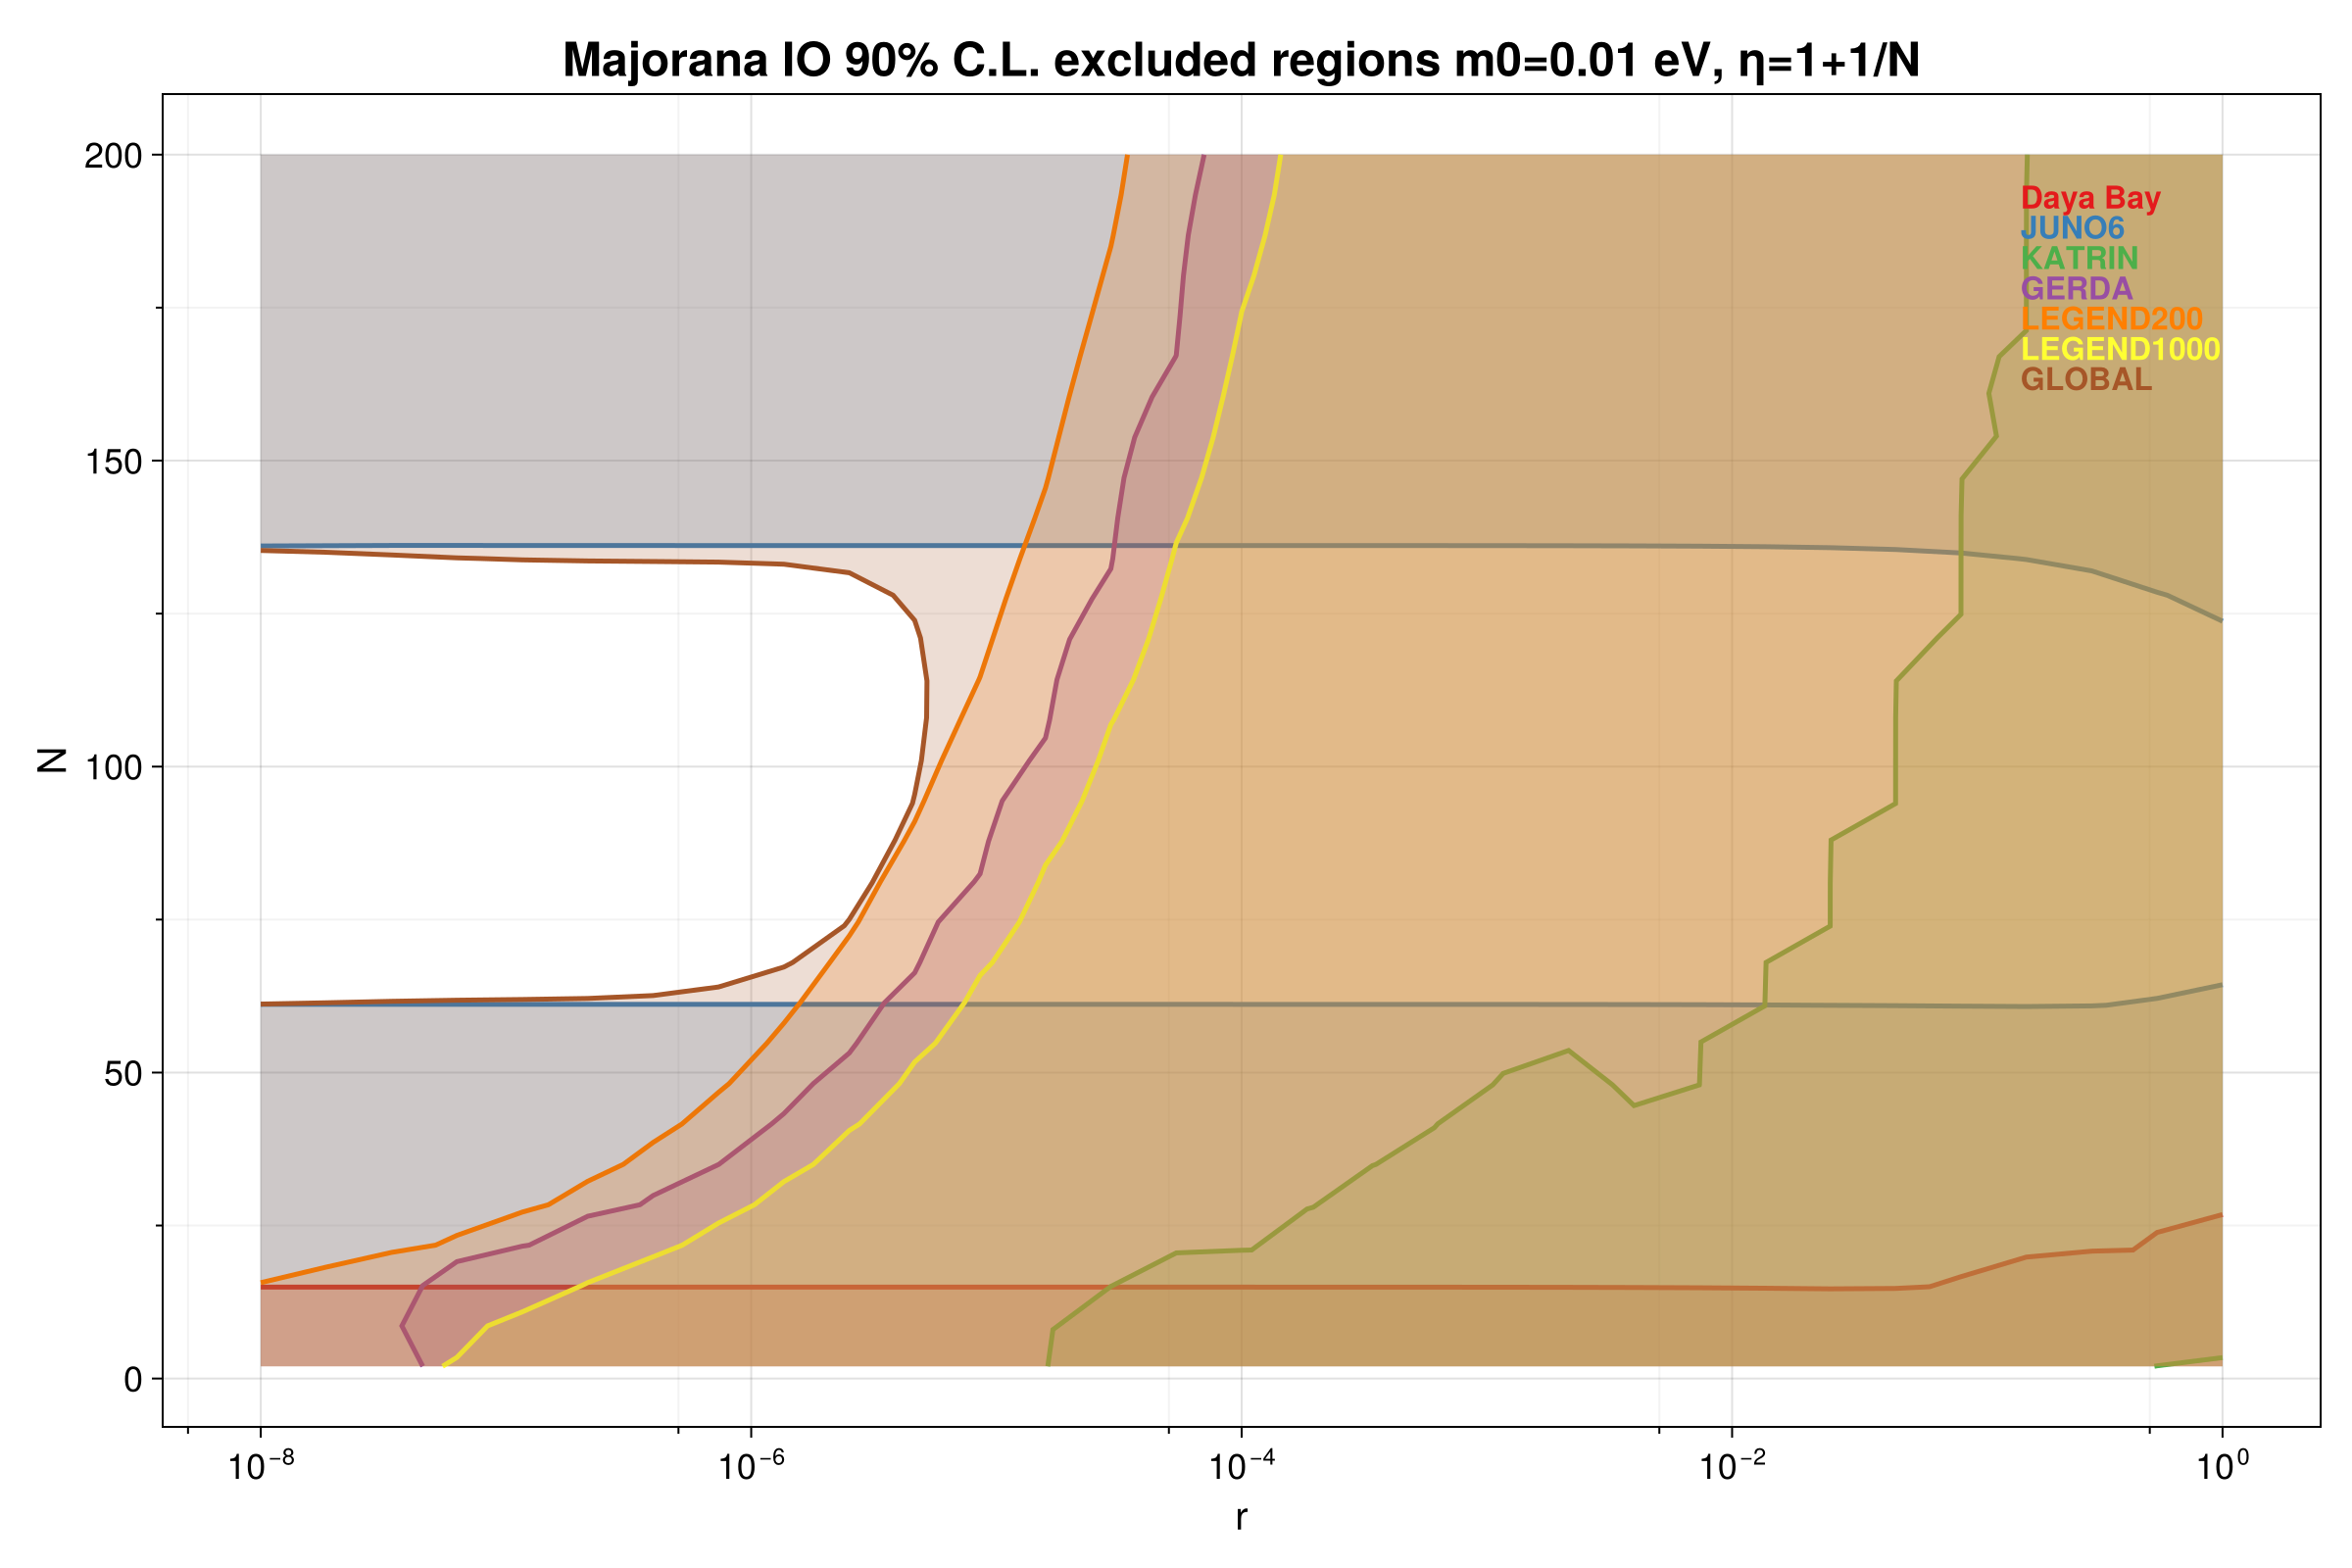

In [16]:
using ImageFiltering
using JLD2, CairoMakie, Distributions, Colors, ColorSchemes
using Newtrinos


function superpose_contours_outside(file_paths::Vector{String}; 
                           title="Superposed Contours",
                           xlabel="Parameter 1", 
                           ylabel="Parameter 2",
                           experiments=nothing,
                           colorscheme=nothing,
                           color_step=1,
                           linestyles=nothing,
                           xscale=identity,
                           yscale=identity,
                           smooth_sigma::Union{Nothing,Float64}=nothing)
 
    
    # Default colorscheme and linestyles
    if colorscheme === nothing
        colorscheme = :Dark2_8
    end
    if linestyles === nothing
        linestyles = fill(:solid, length(file_paths))
    end
    
    # Get colors from the colorscheme with step
    cs = getproperty(ColorSchemes, colorscheme)
    all_colors = cs.colors
    colors = all_colors[1:color_step:end]
    n_colors = length(file_paths)
    if n_colors > length(colors)
        # If we need more colors than available, interpolate
        colors = [colors[i] for i in range(1, length(colors), length=n_colors)]
    else
        colors = colors[1:n_colors]
    end
    

    
  
    sigma_90_excluded_level = quantile(Chisq(2), 0.90)
    
    # Load all results and find axis ranges
    results = []
    all_axes_1 = []
    all_axes_2 = []
    
    for file_path in file_paths
        result = load(file_path)["result"]  # Adjust key if needed
        push!(results, result)
        push!(all_axes_1, result.axes[1])
        push!(all_axes_2, result.axes[2])
    end
    
    # Find combined axis ranges
    x_min = minimum([minimum(ax) for ax in all_axes_1])
    x_max = maximum([maximum(ax) for ax in all_axes_1])
    y_min = minimum([minimum(ax) for ax in all_axes_2])
    y_max = maximum([maximum(ax) for ax in all_axes_2])
        
    # Get axis labels from first result
    first_result = results[1]
    axis_labels = collect(keys(first_result.axes))

    # Create figure
    f = Figure(size=(1200, 800))
    ax = Axis(f[1,1];
        xlabel = String(axis_labels[1]) , #*" (eV)"
        ylabel = String(axis_labels[2]),
        title = title,
        xminorticksvisible = true, 
        xminorgridvisible = true, 
        yminorticksvisible = true, 
        yminorgridvisible = true,
        titlesize = 24,
        xlabelsize = 20,
        ylabelsize = 20,
        xticklabelsize = 18,
        yticklabelsize = 18,
        xscale = xscale,
        yscale = yscale
    )
   # Plot contours
    for (idx, result) in enumerate(results)
        lp = result.values.log_posterior
        finite_mask = isfinite.(lp)

        if !any(finite_mask)
            @warn "Scan contains no finite likelihood values — skipping"
            continue
        end

        lp_max = maximum(lp[finite_mask])

        dLLH_raw = 2 .* (lp_max .- lp)

        dLLH = smooth_sigma === nothing ? dLLH_raw :
            gaussian_smooth(dLLH_raw; σ=smooth_sigma)


        dLLH_plot = copy(dLLH)
        dLLH_plot[.!isfinite.(dLLH_plot)] .= NaN

        maxlevel = maximum(skipmissing(vec(dLLH_plot)))
        ϵ = 1e-6  # numerical safety margin

        color = colors[idx]
        linestyle = linestyles[mod(idx-1, length(linestyles)) + 1]

        color_transparent = RGBA(color, 1.0)
        color_transparent_full = RGBA(color, 0.2)

        # --- SHADE ONLY IF EXCLUSION EXISTS ---
        if isfinite(maxlevel) && maxlevel > sigma_90_excluded_level + ϵ
            contourf!(ax,
                result.axes[1],
                result.axes[2],
                dLLH_plot;
                levels = [sigma_90_excluded_level, maxlevel],
                colormap = cgrad([color_transparent_full, color_transparent])
            )
        end

        # --- ALWAYS DRAW CONTOUR LINE ---
        contour!(ax,
            result.axes[1],
            result.axes[2],
            dLLH_plot;
            levels = [sigma_90_excluded_level],
            color = color,
            linewidth = 2.5,
            linestyle = linestyle
        )
      
        

    end
    if experiments !== nothing
        # Helper function to position in data space (works for log and linear)
        function position_in_range(min_val, max_val, fraction)
            if yscale == log10
                # Log scale: work in log space
                min_log = log10(min_val)
                max_log = log10(max_val)
                return 10 ^ (min_log + fraction * (max_log - min_log))
            else
                # Linear scale: work in linear space
                return min_val + fraction * (max_val - min_val)
            end
        end
        
        fractions_y = range(0.95, 0.80, length=length(experiments))
        y_positions = [position_in_range(y_min, y_max, f) for f in fractions_y]
        x_position = position_in_range(x_min, x_max, 0.15)
        
        for (idx, label) in enumerate(experiments)
            color = colors[idx]
            text!(ax, x_position, y_positions[idx], 
                  text = label,
                  fontsize = 16,
                  color = color,
                  font = :bold)
        end
    end
    
    f
end


file_paths = ["/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_dayabay_rN_m0=0.01_NNM_IO_log.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/junotao_full6_rN_NNM_IO_η=1+1_N_m0=0.01_log.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_katrin_Nr_m0=0.01_η=1+1N_NNM_IO.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_gerda_Nr_m0=0.01_η=1+1N_NNM_IO.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend200_Nr_m0=0.01_η=1+1N_NNM_IO.jld2",
              "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_legend1000_Nr_m0=0.01_η=1+1N_NNM_IO.jld2",
             "/home/sofialon/Newtrinos.jl/plots_fix/scan_new/scan_global_rN_m0=0.01_NNM_IO.jld2"
             ]
    
                
fig = superpose_contours_outside(file_paths;  
    title="Majorana IO 90% C.L. excluded regions m0=0.01 eV, η=1+1/N",
    experiments = ["Daya Bay","JUNO6", "KATRIN","GERDA", "LEGEND200","LEGEND1000","GLOBAL"], 
    colorscheme = :Set1_9,
    color_step = 1,
    xscale=log10,
    #yscale=log10,
    smooth_sigma=0.8)

display("image/png",fig)
save("/home/sofialon/Newtrinos.jl/plots_fix/plots_newex/superposed_contours_allglobal_NNM_IO_rn.png", fig)
